In [1]:
import os, time, copy
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [2]:
DATA_DIR = "data"   # relative to project root
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

# Augmentations for training
train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15),
    transforms.RandomAffine(degrees=0, shear=5, translate=(0.05,0.05)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

# Validation / Test transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

# Load full train folder (we'll split it)
full_train = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
print("Full train images:", len(full_train))
class_names = full_train.classes
print("Classes:", class_names)

# Split into train & val (80/20)
train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train_dataset, val_dataset = random_split(full_train, [train_size, val_size], generator=torch.Generator().manual_seed(seed))

# For validation, we must apply val_transform (override transforms in the subset)
# A small helper to set transform on a Subset's underlying dataset view
val_dataset.dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=val_transform)
val_dataset = torch.utils.data.Subset(val_dataset.dataset, val_dataset.indices)

# Test dataset
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=val_transform)

# Dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("Train:", len(train_dataset), "Val:", len(val_dataset), "Test:", len(test_dataset))


Full train images: 2019
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Train: 1615 Val: 404 Test: 508


In [3]:
class WasteClassifierCNN(nn.Module):
    def __init__(self, num_classes=len(class_names)):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool  = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.4)
        # compute flattened size after 3 poolings on 128x128 -> 128 -> 64 -> 32 -> 16
        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # -> 32x64x64
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # -> 64x32x32
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # ->128x16x16
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = WasteClassifierCNN().to(device)
print(model)


WasteClassifierCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=6, bias=True)
)


In [4]:
# Cell 4
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
# learning rate scheduler helps generalization
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)


D:\Project\Waste management\env\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [5]:
# Cell 5
from tqdm import tqdm

num_epochs = 20
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

for epoch in range(num_epochs):
    t0 = time.time()
    # ---- train ----
    model.train()
    running_loss = 0.0
    running_corrects = 0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Train"):
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels.data).item()
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects / len(train_loader.dataset)

    # ---- validate ----
    model.eval()
    val_running_loss = 0.0
    val_running_corrects = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_running_corrects += torch.sum(preds == labels.data).item()
    val_loss = val_running_loss / len(val_loader.dataset)
    val_acc = val_running_corrects / len(val_loader.dataset)

    # scheduler step based on validation accuracy
    scheduler.step(val_acc)

    elapsed = time.time() - t0
    print(f"Epoch {epoch+1}/{num_epochs}  TrainLoss: {epoch_loss:.4f}  TrainAcc: {epoch_acc*100:.2f}%  ValLoss: {val_loss:.4f}  ValAcc: {val_acc*100:.2f}%  Time: {elapsed:.1f}s")

    # deep copy best model
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())


Epoch 1/20 - Train: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:15<00:00,  3.23it/s]


Epoch 1/20  TrainLoss: 3.8074  TrainAcc: 32.26%  ValLoss: 1.3780  ValAcc: 44.55%  Time: 27.5s


Epoch 2/20 - Train: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:15<00:00,  3.26it/s]


Epoch 2/20  TrainLoss: 1.4878  TrainAcc: 38.95%  ValLoss: 1.2676  ValAcc: 48.51%  Time: 27.3s


Epoch 3/20 - Train: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:15<00:00,  3.32it/s]


...

Epoch 18/20  TrainLoss: 1.1400  TrainAcc: 56.22%  ValLoss: 0.9240  ValAcc: 65.10%  Time: 26.9s


Epoch 19/20 - Train: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:15<00:00,  3.35it/s]


Epoch 19/20  TrainLoss: 1.1406  TrainAcc: 55.05%  ValLoss: 0.8676  ValAcc: 68.56%  Time: 26.7s


Epoch 20/20 - Train: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:15<00:00,  3.39it/s]


Epoch 20/20  TrainLoss: 1.0878  TrainAcc: 58.02%  ValLoss: 0.8747  ValAcc: 67.57%  Time: 26.5s


In [6]:
# Cell 6
# load best
model.load_state_dict(best_model_wts)
model.eval()

# Test evaluation
test_correct = 0
test_total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = test_correct / test_total
print(f"🧾 Test Accuracy: {test_acc*100:.2f}%")


🧾 Test Accuracy: 61.42%


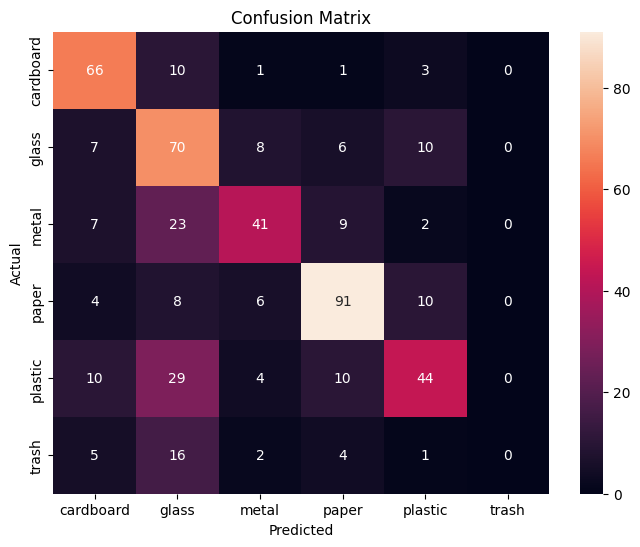

              precision    recall  f1-score   support

   cardboard       0.67      0.81      0.73        81
       glass       0.45      0.69      0.54       101
       metal       0.66      0.50      0.57        82
       paper       0.75      0.76      0.76       119
     plastic       0.63      0.45      0.53        97
       trash       0.00      0.00      0.00        28

    accuracy                           0.61       508
   macro avg       0.53      0.54      0.52       508
weighted avg       0.60      0.61      0.60       508



D:\Project\Waste management\env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Project\Waste management\env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Project\Waste management\env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [8]:
# Cell 7
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()

# classification report
print(classification_report(all_labels, all_preds, target_names=class_names))


In [10]:
# Cell 8
os.makedirs("models", exist_ok=True)
torch.save(best_model_wts, "models/waste_cnn_v2.pth")
print("Model saved to models/waste_cnn_v2.pth")


Model saved to models/waste_cnn_v2.pth


In [12]:
# Cell 9
def predict_image(img_path, model, transform, device=device):
    model.eval()
    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(x)
        probs = torch.softmax(out, dim=1)
        conf, pred = torch.max(probs, 1)
    return class_names[pred.item()], conf.item()

# Example usage:
sample_img = "data/test/plastic/plastic1.jpg"  # change accordingly
label, confidence = predict_image(sample_img, model, val_transform, device)
print("Predicted:", label, "Confidence:", confidence)


Predicted: glass Confidence: 0.34441399574279785
